# Homework 3 Notebook
Code in this notebook contains modularized code to train and probe SimCLR models with various encoders (frozen resnet18 with layer4 frozen/unfrozen, randomly initialized resnet18, “resnet9” implementation), linear probe and MLP probe for SimCLR and an MAE skeleton. As is described in my contribution section of the report

The notebook only runs pretraining/fine-tuning/evaluations on the ResNet9 based SimCLR model 

In [23]:
from scipy.io import loadmat
import numpy as np

import requests
import tarfile

from pathlib import Path
import re
import shutil
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.io import decode_image
from torch.utils.data import Dataset
from torchinfo import summary
import os
from matplotlib import pyplot as plt

import math
from dataclasses import dataclass

import torch.nn.functional as F



device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# define directory names
root_dir = './data'
src_dir = './data/jpg' # this is just where i have all the pics
train_dir = './data/train'
val_dir = './data/val'
test_dir = './data/test'


## Data splits

In [2]:
def download_file(url, download_path):
    # Download the file with streaming to handle large files efficiently
    print(f"Downloading from: {url}")
    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status() # Raise an exception for bad status codes
            with open(download_path, 'wb') as f:
                shutil.copyfileobj(r.raw, f)
        print(f"Download complete: {download_path}")
    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

def download_and_extract_tgz(url, download_path, extract_path):
    # 1. Ensure the extract directory exists
    os.makedirs(extract_path, exist_ok=True)
    print(f"Ensured extraction directory exists: {extract_path}")

    # 2. Download the file with streaming to handle large files efficiently
    print(f"Downloading from: {url}")
    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status() # Raise an exception for bad status codes
            with open(download_path, 'wb') as f:
                shutil.copyfileobj(r.raw, f)
        print(f"Download complete: {download_path}")

        # 3. Extract the .tgz file
        print(f"Extracting to: {extract_path}")
        with tarfile.open(download_path, 'r:gz') as tar_file:
            tar_file.extractall(path=extract_path)
        print("Extraction complete.")

    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")
    except tarfile.TarError as e:
        print(f"Extraction failed: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        # Optional: Remove the downloaded .tgz file after extraction
        if os.path.exists(download_path):
            os.remove(download_path)
            print(f"Removed temporary download file: {download_path}")

In [3]:
# download dataset:
dataset_url = 'https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz'
temp_file_name = 'images.tgz'
destination_folder = './data'
download_and_extract_tgz(dataset_url, temp_file_name, destination_folder)

# download metadata files
metadata_files = [('https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat','./data/imagelabels.mat'),
                  ('https://www.robots.ox.ac.uk/~vgg/data/flowers/102/setid.mat', './data/setid.mat')
                  ]

for url, file in metadata_files:
    download_file(url, file)

Ensured extraction directory exists: ./data
Removed temporary download file: images.tgz


KeyboardInterrupt: 

In [4]:
def ensure_split_folder(split_dir, split_ids, labels, source_dir="./data/jpg"):
    source_path = Path(source_dir)
    target_path = Path(split_dir)

    if target_path.exists():
        print(f"{target_path} already exists; skipping creation.")
        return target_path

    target_path.mkdir(parents=True, exist_ok=True)
    split_id_set = set(np.asarray(split_ids).reshape(-1).astype(int).tolist())
    labels_arr = np.asarray(labels).reshape(-1).astype(int)

    copied = 0
    for file_path in tqdm(source_path.iterdir()):
        if not file_path.is_file():
            continue

        match = re.search(r"(\d+)(?!.*\d)", file_path.stem)
        if not match:
            continue

        sample_id = int(match.group(1))
        if sample_id not in split_id_set:
            continue

        label = int(labels_arr[sample_id - 1])
        label_dir = target_path / str(label)
        label_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy2(file_path, label_dir / file_path.name)
        copied += 1

    print(f"Created {target_path} with {copied} files.")
    return target_path


In [5]:
# define directory names
root_dir = './data'
src_dir = './data/jpg' # this is just where i have all the pics
train_dir = './data/train'
val_dir = './data/val'
test_dir = './data/test'

# load in set splits
# it looks like the train and test set ids are swapped for some reason? 
# test has 6000 examples, and train only has 1000 (same as val)
# swap these here so that we actually train on training data
setid = loadmat("./data/setid.mat")
labels = loadmat("./data/imagelabels.mat")['labels']
test = setid['trnid']
val = setid['valid']
train = setid['tstid']

# split data into train, val, test
# we just copyin for now since the dataset is so small
ensure_split_folder(train_dir, train, labels)
ensure_split_folder(val_dir, val, labels)
ensure_split_folder(test_dir, test, labels)


data/train already exists; skipping creation.
data/val already exists; skipping creation.
data/test already exists; skipping creation.


PosixPath('data/test')

In [6]:
print(setid['trnid'].shape)
print(setid['tstid'].shape)
print(setid['valid'].shape)

(1, 1020)
(1, 6149)
(1, 1020)


## DataLoader definitions

In [2]:
# first calculate stats on the train set for transformation normalization
# mean = 0
# std = 0
# n = 0

# all_paths = [p for p in Path(train_dir).rglob("*") if p.is_file()]

# for path in all_paths:
#     img = decode_image(str(path)).float().to(device)

#     img = img.view(3, -1)
#     mean += img.mean(1).to('cpu')
#     std += img.std(1).to('cpu')
#     n += 1

# mean /= n
# std /= n

# or take mean and std from image net
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

In [3]:
# dataset is small and can be loaded onto gpu, so do that to speed up training
def make_gpu_dataset(directory: Path, transform, two_view: bool = True):
    dataset = ImageFolder(
        root=directory,
        transform=transform
        )
    
    all_images = []
    all_labels = []

    # Iterate through the dataset and collect all items (this may take time)
    for i in tqdm(range(len(dataset))):
        if two_view:
            (view1, view2), label = dataset[i]
            views = torch.stack((view1, view2))
        else:
            views, label = dataset[i]
        all_images.append(views)
        all_labels.append(label)
    # Stack the list of tensors into single large tensors
    # Use torch.stack to combine the list of individual image tensors
    images_tensor = torch.stack(all_images)
    labels_tensor = torch.tensor(all_labels)

    # Move the entire tensors to the specified device (GPU)
    images_gpu = images_tensor.to(device)
    labels_gpu = labels_tensor.to(device)

    print(f"Dataset loaded to GPU. Images shape: {images_gpu.shape}, Labels shape: {labels_gpu.shape}")

    # Wrap the GPU tensors in a TensorDataset
    gpu_dataset = TensorDataset(images_gpu, labels_gpu)

    # Create a DataLoader for batching (batch size can be large, limited by VRAM)
    return gpu_dataset

In [4]:
# two views for contrastive objective
class TwoViewTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, x):
        view1 = self.base_transform(x)
        view2 = self.base_transform(x)
        return view1, view2
    
simclr_train_val_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomApply(
        [T.ColorJitter(0.4, 0.4, 0.4, 0.1)],
        p=0.8
    ),
    #T.RandomGrayscale(p=0.2), # OG SimCLR doesnt use this
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(mean, std)
])
simclr_test_transform = T.Compose([T.RandomResizedCrop(224, scale=(0.6, 1.0)),
                                   T.ToTensor(),
                                   T.Normalize(mean, std)])

### ATTENTION ###
### if you don't want the added speed or need the GPU memory, set this to false
load_data_directly_onto_gpu = True
if load_data_directly_onto_gpu:    
    train_set = make_gpu_dataset(train_dir, TwoViewTransform(simclr_train_val_transform))
else:
    train_set = ImageFolder(
        root=train_dir,
        transform=TwoViewTransform(simclr_train_val_transform)
        )    


100%|██████████| 6149/6149 [02:48<00:00, 36.58it/s]


Dataset loaded to GPU. Images shape: torch.Size([6149, 2, 3, 224, 224]), Labels shape: torch.Size([6149])


In [5]:
train_loader = DataLoader(train_set, 
                          batch_size=512, 
                          shuffle=True, 
                          num_workers=0, 
                          drop_last=True)


torch.Size([3, 3, 224, 224])


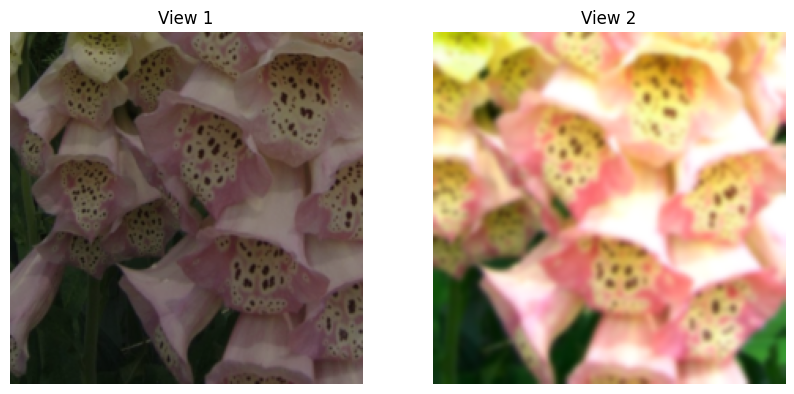

In [29]:
# Visualize the two views of the first training example
images, labels = next(iter(train_loader))
print(images[0].shape)
view1, view2 = images[0][0], images[1][0]

# # Denormalize for visualization
mean_tensor = torch.tensor(mean).view(3, 1, 1)
std_tensor = torch.tensor(std).view(3, 1, 1)
view1_denorm = view1 * std_tensor + mean_tensor
view2_denorm = view2 * std_tensor + mean_tensor

# Plot the two views
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(view1_denorm.permute(1, 2, 0).cpu().numpy().clip(0, 1))
ax[0].set_title('View 1')
ax[0].axis('off')
ax[1].imshow(view2_denorm.permute(1, 2, 0).cpu().numpy().clip(0, 1))
ax[1].set_title('View 2')
ax[1].axis('off')
plt.show()

## SimCLR Models

In [6]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = out + x
        return self.relu(out)


class ResNet9Encoder(nn.Module):
    def __init__(self, in_channels=3, feat_dim=512):
        super().__init__()
        self.feat_dim = feat_dim
        self.stem = nn.Sequential(
            ConvBNReLU(in_channels, 32, 7, 2, 3),
            ConvBNReLU(32, 64, 3, 2, 1),
            nn.MaxPool2d(2),
        )
        self.res1 = ResidualBlock(64)

        self.mid = nn.Sequential(
            ConvBNReLU(64, 128, 3, 1, 1),
            nn.MaxPool2d(2),
            ConvBNReLU(128, 256, 3, 1, 1),
            nn.MaxPool2d(2),
        )
        self.res2 = ResidualBlock(256)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, feat_dim)

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(x)
        x = self.mid(x)
        x = self.res2(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class ResNet18Encoder(nn.Module):
    def __init__(self, freeze: bool = True, retrain_layer4: bool = True):
        super().__init__()

        if freeze:
            weights = ResNet18_Weights.DEFAULT
            self.resnet18 = resnet18(weights=weights)
        else:
            self.resnet18 = resnet18(weights=None)

        # replace last layer with linear projection head
        self.resnet18.fc = nn.Identity()

        if freeze:
            for param in self.resnet18.parameters():
                param.requires_grad = False
        
        if freeze and retrain_layer4:
            # Unfreeze the parameters in the last block (layer4)
            for param in self.resnet18.layer4.parameters():
                param.requires_grad = True

        # Unfreeze the parameters in the new fully connected layer (fc)
        for param in self.resnet18.fc.parameters():
            param.requires_grad = True
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.resnet18(x)

class SimCLR(nn.Module):
    def __init__(self, encoder: nn.Module, 
                 encoder_out_features: int, 
                 out_features=128):
        super().__init__()
        
        self.encoder = encoder

        # projection head
        self.projector = nn.Sequential(
            nn.Linear(encoder_out_features, 256),
            nn.ReLU(),
            nn.Linear(256, out_features)
        )      

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y_pred = self.encoder(x)
        y_pred = self.projector(y_pred)
        return y_pred
    
    @torch.no_grad()
    def representation(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

## NT-XENT loss function

In [7]:
import torch
import torch.nn.functional as F

def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.2) -> torch.Tensor:
    if z1.ndim != 2 or z2.ndim != 2:
        raise ValueError(f"z1 and z2 must be 2D (B,D). Got {z1.shape} and {z2.shape}.")
    if z1.shape != z2.shape:
        raise ValueError(f"z1 and z2 must have the same shape. Got {z1.shape} vs {z2.shape}.")

    B, D = z1.shape
    if B < 2:
        raise ValueError("Batch size must be >= 2 for contrastive loss (needs negatives).")

    # concatenate for a (2B, D) tensor
    z = torch.cat([z1, z2], dim=0)  # (2B, D)

    # cosine similarity
    sim = F.cosine_similarity(z[None,:,:], z[:,None,:], dim=-1)
    
    # mask self similarity
    sim[torch.eye(z.size(0)).bool()] = float("-inf")

    # positive indices:
    # For i in [0..B-1] (z1), positive is i+B (z2)
    # For i in [B..2B-1] (z2), positive is i-B (z1)
    pos_idx = torch.arange(2 * B, device=z.device)
    pos_idx = (pos_idx + B) % (2 * B)

    # cross-entropy loss where each anchor predicts its positive among 2B-1 candidates
    # Targets: for each row i, the positive is at column pos_idx[i]
    loss = F.cross_entropy(sim/temperature, pos_idx)

    return loss

## Train SimCLR

In [8]:
def train_simCLR_model(model: nn.Module, 
                       train_loader: DataLoader, 
                       epochs: int, 
                       lr: float):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    results = {"train_loss": [], "val_loss": []}
    for ep in range(1, epochs + 1):
        running = 0.0
        n_batches = 0
        pbar = tqdm(train_loader, desc=f"epoch {ep}/{epochs}", leave=False)
        
        model.train()
        for sample in pbar:
            views, _ = sample
            x1 = views[:,0,:,:,:]
            x2 = views[:,1,:,:,:]

            z1 = model(x1)
            z2 = model(x2)
        
            loss = nt_xent_loss(z1, z2)
            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.item())
            n_batches += 1
            pbar.set_postfix(loss=running / n_batches)
        
        train_loss = running / max(1, n_batches)
        results["train_loss"].append(train_loss)
    
        if ep % 10 == 0:
            print(f"epoch {ep}: train_loss={train_loss:.4f}")
    results['model'] = model
    return results

In [9]:
encoder = ResNet9Encoder()
simCLR = SimCLR(encoder, 512)

lr = 1e-3
epochs = 100
results = train_simCLR_model(simCLR, train_loader, epochs, lr)


epoch 10: train_loss=3.3610


epoch 20: train_loss=2.9348


epoch 30: train_loss=2.7108


epoch 40: train_loss=2.5863


epoch 50: train_loss=2.5141


epoch 60: train_loss=2.4473


epoch 70: train_loss=2.3974


epoch 80: train_loss=2.3629


epoch 90: train_loss=2.3358


epoch 100: train_loss=2.3140


In [22]:
summary(simCLR)

Layer (type:depth-idx)                             Param #
SimCLR                                             --
├─ResNet9Encoder: 1-1                              --
│    └─Sequential: 2-1                             --
│    │    └─ConvBNReLU: 3-1                        4,768
│    │    └─ConvBNReLU: 3-2                        18,560
│    │    └─MaxPool2d: 3-3                         --
│    └─ResidualBlock: 2-2                          --
│    │    └─Sequential: 3-4                        73,984
│    │    └─ReLU: 3-5                              --
│    └─Sequential: 2-3                             --
│    │    └─ConvBNReLU: 3-6                        73,984
│    │    └─MaxPool2d: 3-7                         --
│    │    └─ConvBNReLU: 3-8                        295,424
│    │    └─MaxPool2d: 3-9                         --
│    └─ResidualBlock: 2-4                          --
│    │    └─Sequential: 3-10                       1,180,672
│    │    └─ReLU: 3-11                            

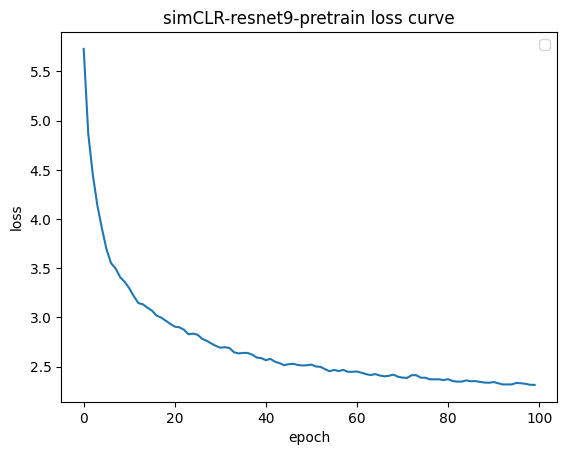

In [10]:
from matplotlib import pyplot as plt
plt.title("simCLR-resnet9-pretrain loss curve")
plt.legend(['train loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.plot(results['train_loss'])

## Evaluate with linear probe

In [11]:
probe_train_set = make_gpu_dataset(train_dir, simclr_test_transform, False)
probe_val_set = make_gpu_dataset(val_dir, simclr_test_transform, False)
probe_test_set = make_gpu_dataset(test_dir, simclr_test_transform, False)

100%|██████████| 6149/6149 [00:33<00:00, 185.45it/s]


Dataset loaded to GPU. Images shape: torch.Size([6149, 3, 224, 224]), Labels shape: torch.Size([6149])


100%|██████████| 1020/1020 [00:05<00:00, 187.40it/s]


Dataset loaded to GPU. Images shape: torch.Size([1020, 3, 224, 224]), Labels shape: torch.Size([1020])


100%|██████████| 1020/1020 [00:05<00:00, 195.83it/s]


Dataset loaded to GPU. Images shape: torch.Size([1020, 3, 224, 224]), Labels shape: torch.Size([1020])


In [12]:
probe_train_loader = DataLoader(probe_train_set, 
                          batch_size=128, 
                          shuffle=True, 
                          num_workers=0, 
                          drop_last=True)

probe_val_loader = DataLoader(probe_val_set, 
                          batch_size=128, 
                          shuffle=True, 
                          num_workers=0, 
                          drop_last=True)

probe_test_loader = DataLoader(probe_test_set, 
                          batch_size=128, 
                          shuffle=True, 
                          num_workers=0, 
                          drop_last=True)

In [13]:
def train_classifier(encoder: nn.Module,
                     classifier: nn.Module, 
                     train_loader: DataLoader,
                     val_loader: DataLoader,
                     epochs: int, 
                     lr: float):
    
    results = {"train_loss": [], "val_loss": []}
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)
    
    encoder.eval()
    for epoch in range(epochs):
        train_loss = 0
        train_running = 0
        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{epochs}", leave=False)
        n_batches = 0
        for sample in pbar:
            view, label = sample
            with torch.no_grad():
                features = encoder.representation(view)

            outputs = classifier(features)
            loss = criterion(outputs, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_running += float(loss.item())
            n_batches += 1
            pbar.set_postfix(loss=train_running / n_batches)
        
        train_loss = train_running / max(1, n_batches)
        
        val_loss = 0
        val_running = 0
        with torch.no_grad():
            n_batches = 0
            for sample in val_loader:
                features = encoder.representation(view)
                outputs = classifier(features)
                loss = criterion(outputs, label)
                val_running += float(loss.item())
                n_batches += 1

        val_loss = val_running / max(1, n_batches)
        results["train_loss"].append(train_loss)
        results["val_loss"].append(val_loss)
        if epoch % 10 == 0:
            print(f"epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    results['classifier'] = classifier
    return results
    

In [14]:
linear_probe = nn.Linear(512, 102).to(device)
epochs = 250
lr = 1e-3
classifier_results = train_classifier(simCLR, linear_probe, probe_train_loader, probe_val_loader, epochs, lr)

epoch 0: train_loss=3.4303, val_loss=2.9881


epoch 10: train_loss=2.1278, val_loss=2.0867


epoch 20: train_loss=1.9244, val_loss=1.8331


epoch 30: train_loss=1.8068, val_loss=1.7566


epoch 40: train_loss=1.7145, val_loss=1.9888


...

epoch 200: train_loss=1.1780, val_loss=1.2175


epoch 210: train_loss=1.1599, val_loss=1.2562


epoch 220: train_loss=1.1421, val_loss=1.2315


epoch 230: train_loss=1.1295, val_loss=1.1697


epoch 240: train_loss=1.1094, val_loss=1.0122


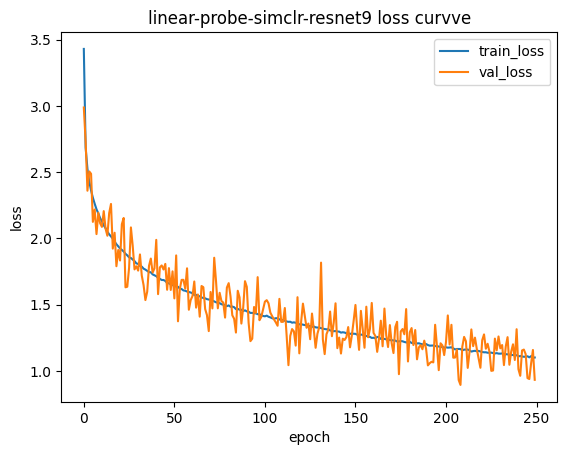

In [15]:
from matplotlib import pyplot as plt
plt.title('linear-probe-simclr-resnet9 loss curvve')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.plot(classifier_results['train_loss'])
plt.plot(classifier_results['val_loss'])
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [16]:
def evaluate(model, classifier, loader):
    model.eval()
    classifier.eval()
    
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            features = model.representation(images)
            outputs = classifier(features)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [17]:
train_acc = evaluate(simCLR, linear_probe, probe_train_loader)
val_acc = evaluate(simCLR, linear_probe, probe_val_loader)
test_acc = evaluate(simCLR, linear_probe, probe_test_loader)

print("linear probe accuracy:")
print("Train:", train_acc)
print("Val:", val_acc)
print("Test:", test_acc)

linear probe accuracy:
Train: 0.7190755208333334
Val: 0.5044642857142857
Test: 0.48214285714285715


## Evaluate with mlp

In [18]:
class MLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

In [19]:
mlp = MLP(512, 256, 128).to(device)
epochs = 250
lr = 1e-3
classifier_results = train_classifier(simCLR, mlp, probe_train_loader, probe_val_loader, epochs, lr)

epoch 0: train_loss=3.4093, val_loss=2.7543


epoch 10: train_loss=1.6952, val_loss=1.3669


epoch 20: train_loss=1.2663, val_loss=1.2045


epoch 30: train_loss=1.0005, val_loss=0.9676


epoch 40: train_loss=0.7763, val_loss=0.7836


...

epoch 200: train_loss=0.0120, val_loss=0.0102


epoch 210: train_loss=0.0106, val_loss=0.0116


epoch 220: train_loss=0.0096, val_loss=0.0107


epoch 230: train_loss=0.0108, val_loss=0.0088


epoch 240: train_loss=0.0321, val_loss=0.0156


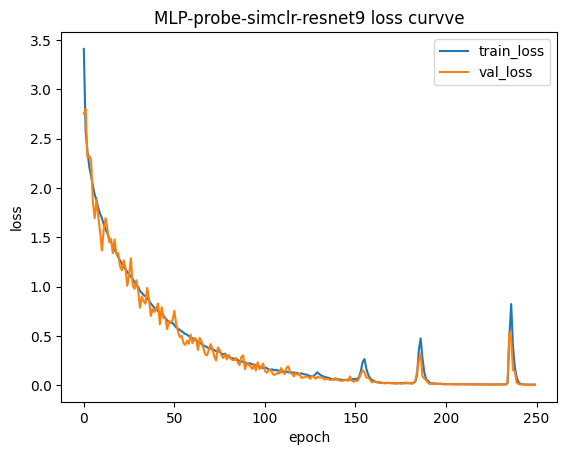

In [20]:
from matplotlib import pyplot as plt
plt.title('MLP-probe-simclr-resnet9 loss curvve')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.plot(classifier_results['train_loss'])
plt.plot(classifier_results['val_loss'])
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [21]:
train_acc = evaluate(simCLR, mlp, probe_train_loader)
val_acc = evaluate(simCLR, mlp, probe_val_loader)
test_acc = evaluate(simCLR, mlp, probe_test_loader)

print("MLP accuracy:")
print("Train:", train_acc)
print("Val:", val_acc)
print("Test:", test_acc)

MLP accuracy:
Train: 1.0
Val: 0.43973214285714285
Test: 0.42857142857142855


## Masked autoencoder skeleton

In [ ]:
# ------------------------------------------------------------
# Config
# ------------------------------------------------------------

@dataclass
class MAEConfig:
    img_size: int = 224
    patch_size: int = 16
    in_chans: int = 3

    enc_embed_dim: int = 384
    enc_depth: int = 12
    enc_num_heads: int = 12
    mlp_ratio: float = 4.0

    dec_embed_dim: int = 512
    dec_depth: int = 8
    dec_num_heads: int = 16

    mask_ratio: float = 0.75
    norm_pix_loss: bool = True


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

class PatchEmbed(nn.Module):
    """
    Standard ViT-style patch embedding using a Conv2d with
    kernel_size = stride = patch_size.
    """

    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        assert img_size % patch_size == 0
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size

        self.proj = nn.Conv2d(
            in_chans, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W]
        returns: [B, L, D]
        """
        x = self.proj(x)                  # [B, D, Gh, Gw]
        x = x.flatten(2).transpose(1, 2) # [B, L, D]
        return x


class MLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


class TransformerBlock(nn.Module):
    """
    Minimal ViT block scaffold.

    TODO:
      - swap with timm VisionTransformer block
      - Add dropout / droppath if desired
    """

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

class MaskedAutoencoderViT(nn.Module):
    """
    MAE scaffold matching the paper's core design:
      1. patchify image
      2. randomly mask patches
      3. encoder sees only visible patches
      4. decoder receives encoded visible tokens + mask tokens
      5. reconstruct pixels
      6. loss only on masked patches
    """

    def __init__(self, cfg: MAEConfig):
        super().__init__()
        self.cfg = cfg

        # ----- patch embedding -----
        self.patch_embed = PatchEmbed(
            img_size=cfg.img_size,
            patch_size=cfg.patch_size,
            in_chans=cfg.in_chans,
            embed_dim=cfg.enc_embed_dim,
        )
        num_patches = self.patch_embed.num_patches

        # ----- encoder -----
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.enc_embed_dim))
        self.pos_embed_enc = nn.Parameter(
            torch.zeros(1, num_patches + 1, cfg.enc_embed_dim),
            requires_grad=False,  # fixed sin-cos in original MAE
        )

        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(cfg.enc_embed_dim, cfg.enc_num_heads, cfg.mlp_ratio)
            for _ in range(cfg.enc_depth)
        ])
        self.enc_norm = nn.LayerNorm(cfg.enc_embed_dim)

        # ----- decoder -----
        self.decoder_embed = nn.Linear(cfg.enc_embed_dim, cfg.dec_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, cfg.dec_embed_dim))

        self.pos_embed_dec = nn.Parameter(
            torch.zeros(1, num_patches + 1, cfg.dec_embed_dim),
            requires_grad=False,
        )

        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(cfg.dec_embed_dim, cfg.dec_num_heads, cfg.mlp_ratio)
            for _ in range(cfg.dec_depth)
        ])
        self.dec_norm = nn.LayerNorm(cfg.dec_embed_dim)

        patch_dim = cfg.patch_size * cfg.patch_size * cfg.in_chans
        self.decoder_pred = nn.Linear(cfg.dec_embed_dim, patch_dim)

        self.initialize_weights()

    # --------------------------------------------------------
    # initialization
    # --------------------------------------------------------

    def initialize_weights(self):
        """
        TODO:
          - Fill fixed sin-cos positional embeddings
          - Init cls token, mask token, and linear weights
        """
        grid = self.patch_embed.grid_size

        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.xavier_uniform_(m.weight.view(m.weight.shape[0], -1))
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    # --------------------------------------------------------
    # patch utilities
    # --------------------------------------------------------

    def patchify(self, imgs: torch.Tensor) -> torch.Tensor:
        """
        imgs: [B, C, H, W]
        returns patches: [B, L, patch_size^2 * C]
        """
        p = self.cfg.patch_size
        B, C, H, W = imgs.shape
        assert H == W and H % p == 0

        h = w = H // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = torch.einsum("nchpwq->nhwpqc", x)
        x = x.reshape(B, h * w, p * p * C)
        return x

    def unpatchify(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, L, patch_size^2 * C]
        returns imgs: [B, C, H, W]
        """
        p = self.cfg.patch_size
        B, L, D = x.shape
        h = w = int(L ** 0.5)
        assert h * w == L
        C = self.cfg.in_chans
        assert D == p * p * C

        x = x.reshape(B, h, w, p, p, C)
        x = torch.einsum("nhwpqc->nchpwq", x)
        imgs = x.reshape(B, C, h * p, w * p)
        return imgs

    # --------------------------------------------------------
    # masking
    # --------------------------------------------------------

    def random_masking(self, x: torch.Tensor, mask_ratio: float):
        """
        Per-sample random masking by per-sample shuffling.

        x: [B, L, D]
        returns:
          x_masked: [B, L_keep, D]
          mask:     [B, L] where 1 = masked, 0 = kept
          ids_restore: [B, L] indices to undo shuffle
          ids_keep: [B, L_keep]
        """
        B, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))

        noise = torch.rand(B, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(
            x, dim=1,
            index=ids_keep.unsqueeze(-1).expand(-1, -1, D)
        )

        mask = torch.ones(B, L, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore, ids_keep

    # --------------------------------------------------------
    # encoder
    # --------------------------------------------------------

    def forward_encoder(self, imgs: torch.Tensor, mask_ratio: float):
        """
        Encoder sees only visible patches, not mask tokens.
        """
        x = self.patch_embed(imgs)                    # [B, L, D]
        x = x + self.pos_embed_enc[:, 1:, :]         # patch positions only

        x, mask, ids_restore, ids_keep = self.random_masking(x, mask_ratio)

        cls_token = self.cls_token + self.pos_embed_enc[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.enc_norm(x)

        return x, mask, ids_restore

    # --------------------------------------------------------
    # decoder
    # --------------------------------------------------------

    def forward_decoder(self, latent: torch.Tensor, ids_restore: torch.Tensor):
        """
        Reinsert mask tokens after the encoder, then decode all patches.
        """
        x = self.decoder_embed(latent)   # [B, 1 + L_keep, D_dec]

        # split cls / patch tokens
        cls_token = x[:, :1, :]
        x_vis = x[:, 1:, :]              # visible patch tokens only

        B, L_keep, D = x_vis.shape
        L_full = ids_restore.shape[1]
        num_mask = L_full - L_keep

        mask_tokens = self.mask_token.expand(B, num_mask, D)

        x_full = torch.cat([x_vis, mask_tokens], dim=1)  # shuffled order
        x_full = torch.gather(
            x_full, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, D)
        )

        x = torch.cat([cls_token, x_full], dim=1)
        x = x + self.pos_embed_dec

        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.dec_norm(x)

        pred = self.decoder_pred(x[:, 1:, :])  # remove cls token
        return pred  # [B, L, patch_dim]

    # --------------------------------------------------------
    # loss
    # --------------------------------------------------------

    def forward_loss(self, imgs: torch.Tensor, pred: torch.Tensor, mask: torch.Tensor):
        """
        Compute reconstruction loss only on masked patches.

        pred: [B, L, patch_dim]
        mask: [B, L], 1 = masked, 0 = visible
        """
        target = self.patchify(imgs)

        if self.cfg.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.0e-6).sqrt()

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # per patch

        # only masked patches contribute
        loss = (loss * mask).sum() / mask.sum()
        return loss

    # --------------------------------------------------------
    # main forward
    # --------------------------------------------------------

    def forward(self, imgs: torch.Tensor, mask_ratio: float = None):
        if mask_ratio is None:
            mask_ratio = self.cfg.mask_ratio

        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)

        return {
            "loss": loss,
            "pred": pred,
            "mask": mask,
        }

In [7]:
from torchinfo import summary
cfg = MAEConfig()
mae = MaskedAutoencoderViT(cfg)
summary(mae)

Layer (type:depth-idx)                                       Param #
MaskedAutoencoderViT                                         177,408
├─PatchEmbed: 1-1                                            --
│    └─Conv2d: 2-1                                           295,296
├─ModuleList: 1-2                                            --
│    └─TransformerBlock: 2-2                                 --
│    │    └─LayerNorm: 3-1                                   768
│    │    └─MultiheadAttention: 3-2                          591,360
│    │    └─LayerNorm: 3-3                                   768
│    │    └─MLP: 3-4                                         1,181,568
│    └─TransformerBlock: 2-3                                 --
│    │    └─LayerNorm: 3-5                                   768
│    │    └─MultiheadAttention: 3-6                          591,360
│    │    └─LayerNorm: 3-7                                   768
│    │    └─MLP: 3-8                                         1,181,5